In [1]:
# Imports!

import numpy as np 
import matplotlib.pyplot as plt
import nibabel as nib
import sys
import os

sys.path.append(os.path.abspath("../src"))
from denoising.figures.MetabMaps_Fig5 import *
from denoising.figures.FitRates_Fig6 import *
from denoising.figures.GM_WM_Contrast_Fig7 import *

# Fig. 5: Metab Maps

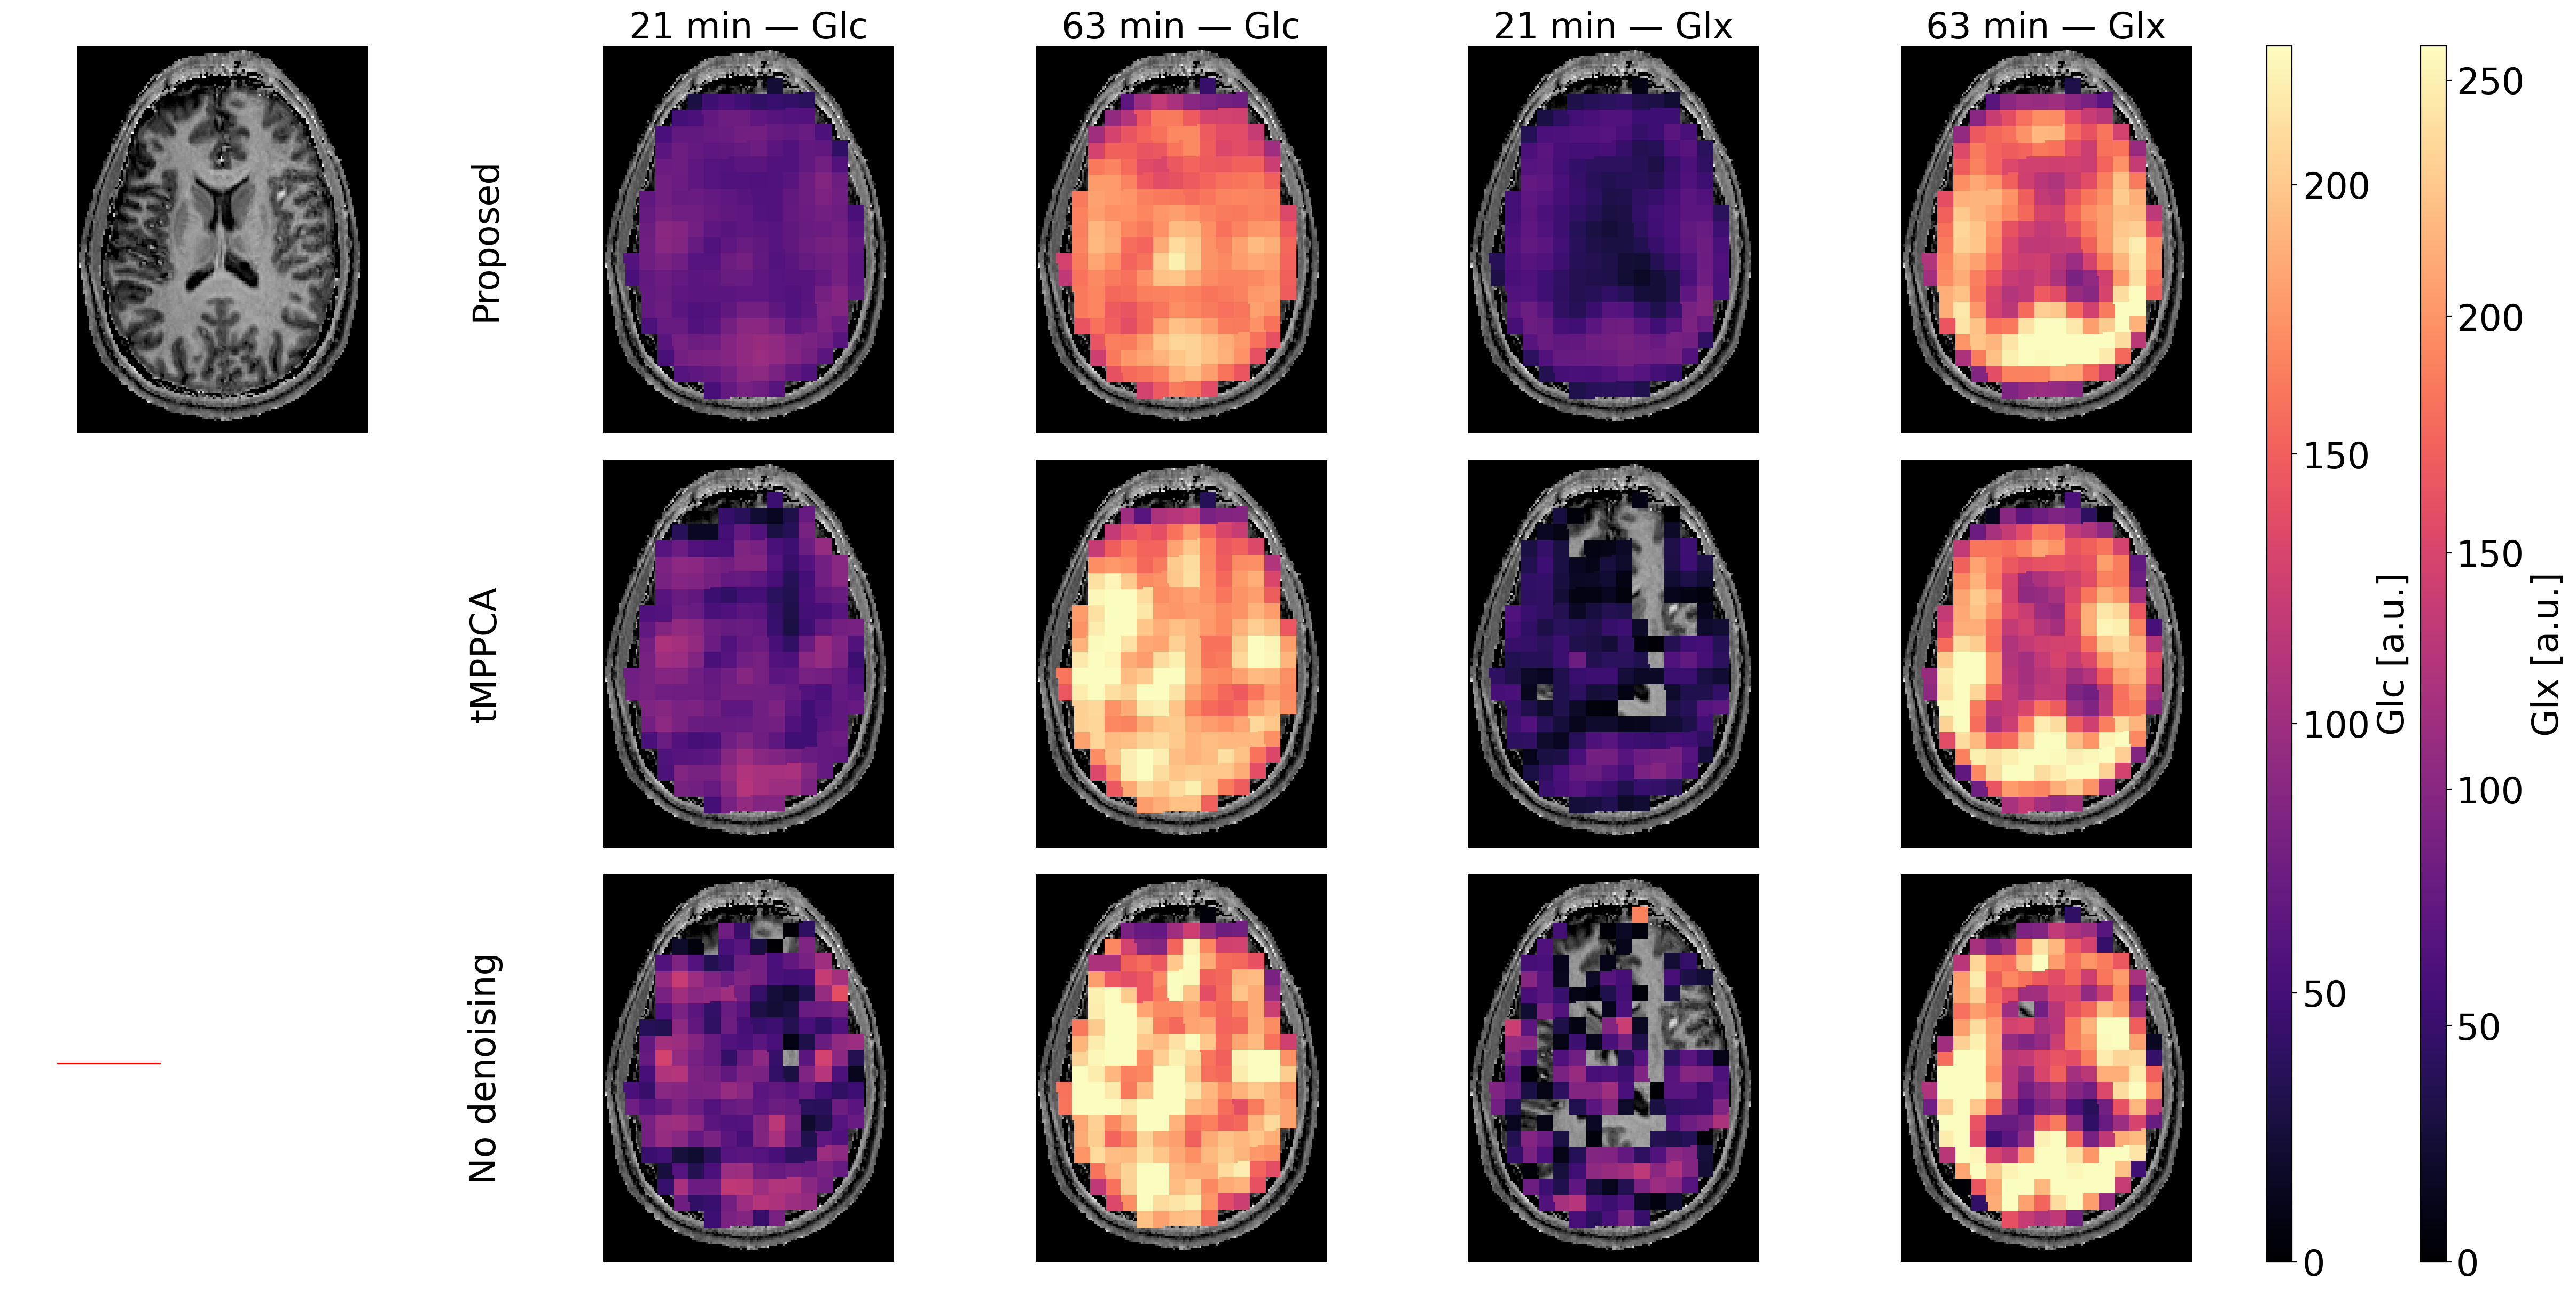

In [2]:
plot_dmi_timecourse_multi(
    BASE_LIST=[
        "MetabMaps/P08_deep_tMPPCA_5D",
        "MetabMaps/P08_tMPPCA_5D",
        "MetabMaps/P08_noisy"
    ],
    T_INDEX_LIST=[2, 8],
    save_path = "SavedGraphics/HealthyMaps.pdf",
    method_labels=["Proposed", "tMPPCA", "No denoising"],
    rep_labels=["21 min", "63 min"],
    DMI_BOX_I=10, DMI_BOX_J=10, DMI_Z=11,
    align_t1_to_dmi=True,
    box_linewidth=0, box_color='red',
    metabolites=("Glc", "Glx"),
    overlay_alpha=1,
    overlay_mask_mode="percentile",   # <- probier "below" oder "percentile"
    overlay_mask_percentile=5.0       # <- mehr = mehr transparent (mehr T1 sichtbar)
    # overlay_mask_mode="below",
    # overlay_mask_value=0.0
)

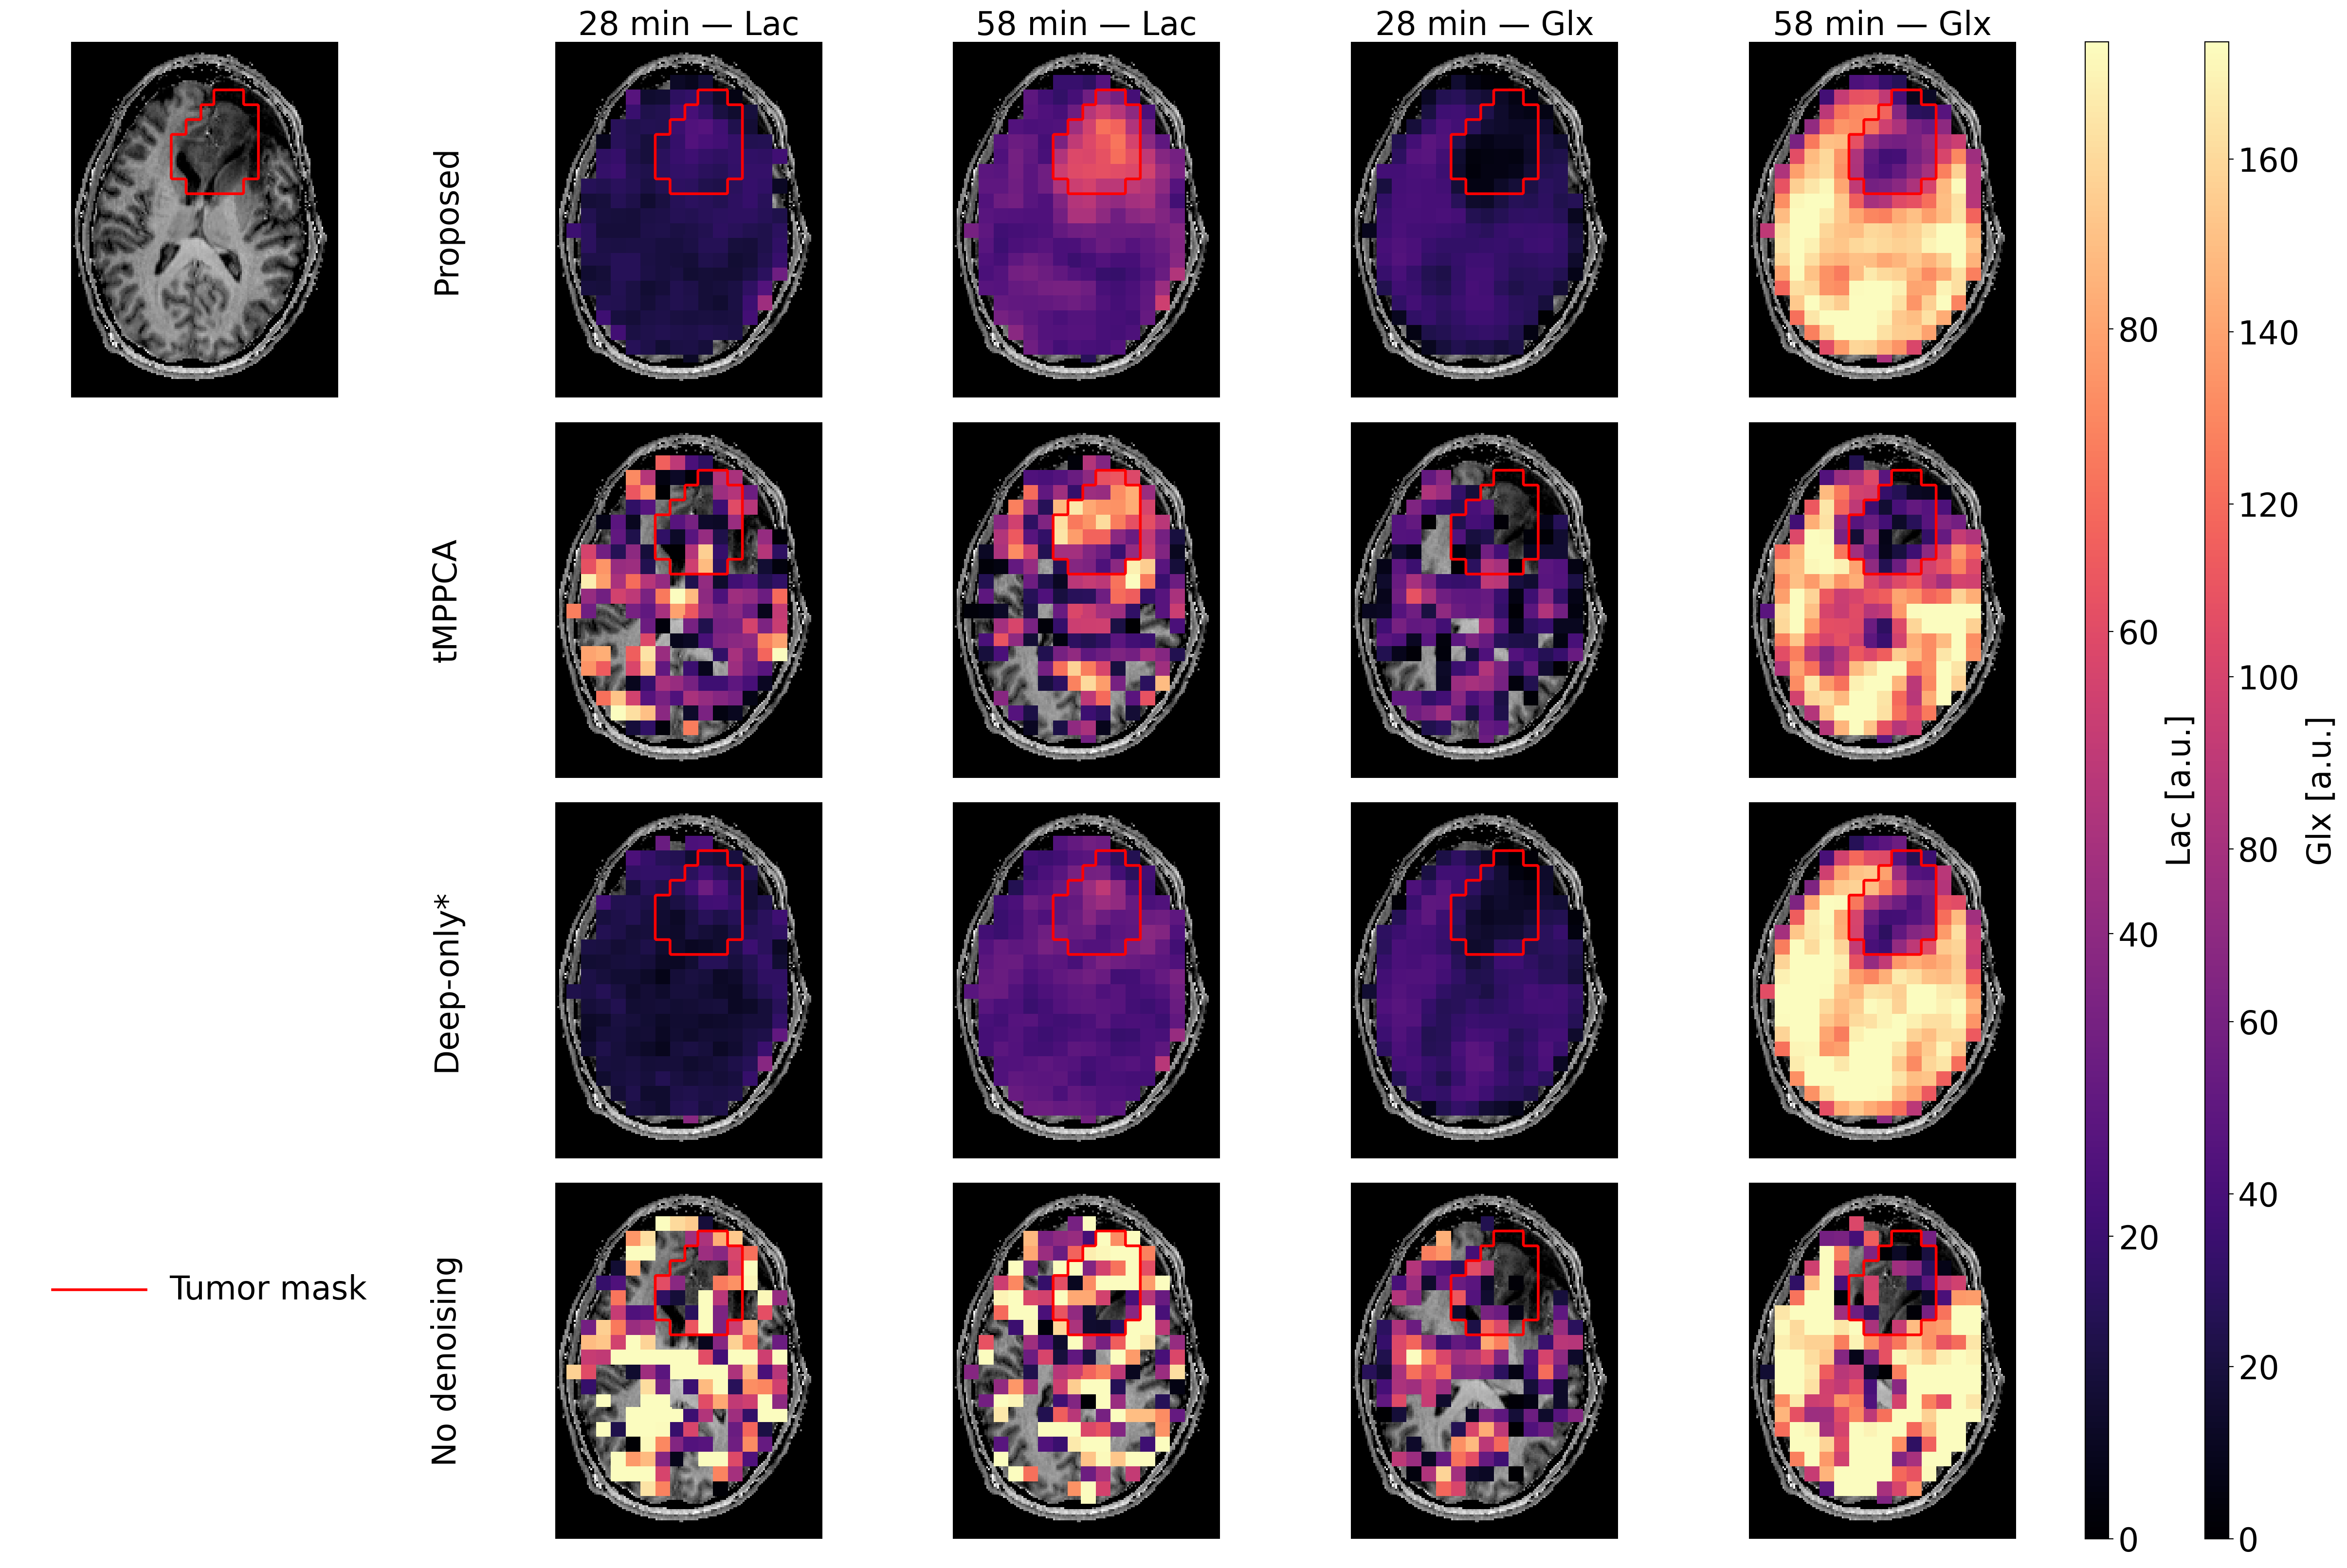

In [3]:
plot_dmi_timecourse_multi(
    BASE_LIST=[
        "MetabMaps/Tumor_1_deep_tMPPCA_5D",
        "MetabMaps/Tumor_1_tMPPCA_5D",
        "MetabMaps/Tumor_1_FullRank_deep",
        "MetabMaps/Tumor_1_noisy"
    ],
    T_INDEX_LIST=[4, 10],
    save_path = "SavedGraphics/TumorMaps.pdf",
    method_labels=["Proposed", "tMPPCA","Deep-only*", "No denoising"],
    rep_labels=["28 min", "58 min"],
    DMI_Z=11,
    align_t1_to_dmi=True,
    metabolites=("Lac", "Glx"),
    overlay_alpha=1.0,
    overlay_mask_mode="percentile",
    overlay_mask_percentile=5.0,
    tumor_mask_filename="Tumor_1_mask.nii",
    tumor_color="red",
    tumor_linewidth=2.0
)

# Fig. 6: Fit Rates

💾 Saved as: SavedGraphics/FitRateHealthy.pdf


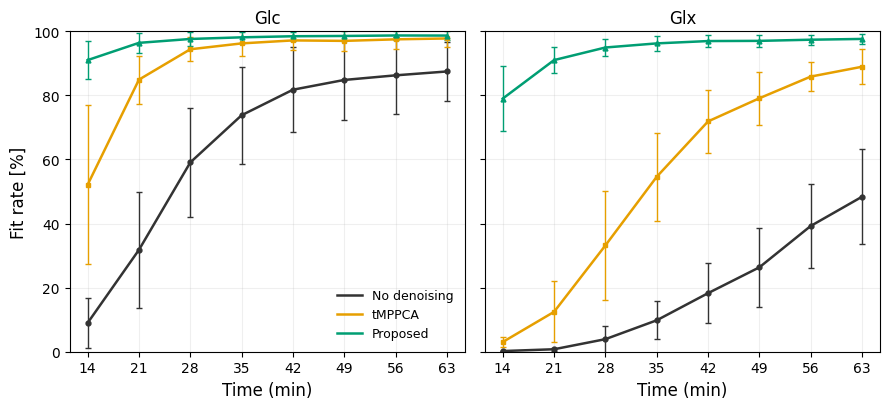

In [4]:
# ===================== EXAMPLE: compute stats + plot =====================
subjects = ["P03", "P04", "P05", "P06", "P07", "P08"]
method_suffixes = ["noisy", "tMPPCA_5D", "deep_tMPPCA_5D"]

stats_glc = fit_rate_group_stats("Glc", subjects, method_suffixes=method_suffixes, crlb_thresh=30)
stats_glx = fit_rate_group_stats("Glx", subjects, method_suffixes=method_suffixes, crlb_thresh=30)

methods = ["P08_noisy", "P08_tMPPCA_5D", "P08_deep_tMPPCA_5D"]
labels  = ["No denoising", "tMPPCA", "Proposed"]

plot_group_fitrate_two_metabs(
    stats_glc=stats_glc,
    stats_glx=stats_glx,
    methods=methods,
    labels=labels,

    title_left="Glc",
    title_right="Glx",
    legend_loc="lower right",
    savepath="SavedGraphics/FitRateHealthy.pdf"
)

💾 Saved as: SavedGraphics/FitRateTumor.pdf


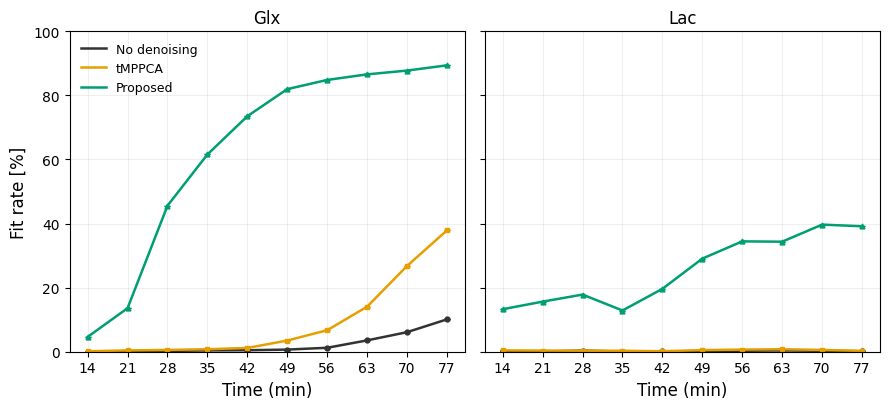

In [5]:
subjects = ["Tumor_1"]
method_suffixes = ["noisy", "tMPPCA_5D", "deep_tMPPCA_5D"]

stats_glc = fit_rate_group_stats("Glx", subjects, method_suffixes=method_suffixes, crlb_thresh=30)
stats_glx = fit_rate_group_stats("Lac", subjects, method_suffixes=method_suffixes, crlb_thresh=30)

methods = ["_noisy", "_tMPPCA_5D", "_deep_tMPPCA_5D"]
labels  = ["No denoising", "tMPPCA", "Proposed"]

plot_group_fitrate_two_metabs(
    stats_glc=stats_glc,
    stats_glx=stats_glx,
    methods=methods,
    labels=labels,
    minutes_per_rep=7.0,
    ymax=100,
    title="",
    savepath="SavedGraphics/FitRateTumor.pdf",

    title_left="Glx",
    title_right="Lac",
    legend_loc="upper left",
)

# Fig. 7: GM/WM Contrast

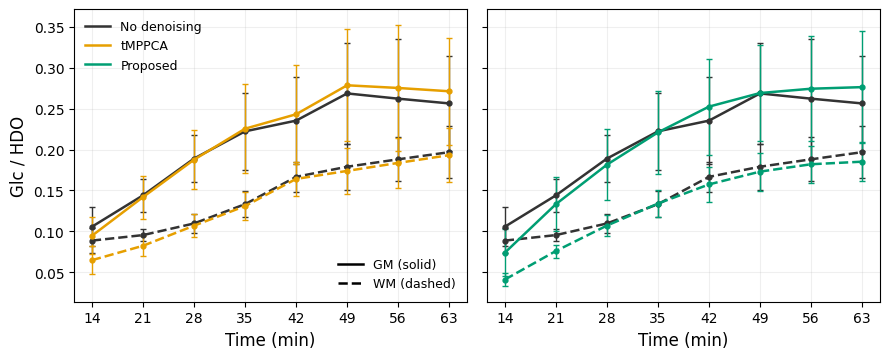

In [6]:
crlb_threshold = 50

method_templates = [
    "{subject}_noisy",
    "{subject}_tMPPCA_5D",
    "{subject}_deep_tMPPCA_5D",
]

subjects = ["P03", "P04", "P05", "P06", "P07", "P08"]

time_minutes = [14, 21, 28, 35, 42, 49, 56, 63]

method_labels = {
    "noisy": "No denoising",
    "tMPPCA_5D": "tMPPCA",
    "deep_tMPPCA_5D": "Proposed",
}

plot_timecourse_metabolite_group_global_water(
    metabolite="Glc",
    method_templates=method_templates,
    subjects=subjects,
    time_minutes=time_minutes,
    y_label="Glc / HDO",
    method_labels=method_labels,
    crlb_threshold=crlb_threshold
)

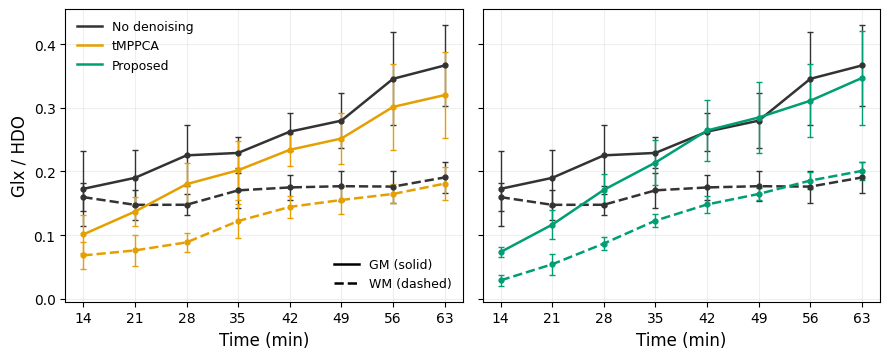

In [7]:
plot_timecourse_metabolite_group_global_water(
    metabolite="Glx",
    method_templates=method_templates,
    subjects=subjects,
    time_minutes=time_minutes,
    y_label="Glx / HDO",
    method_labels=method_labels,
    crlb_threshold=crlb_threshold
)